
Ce notebook explore les trois sources de données du papier **avant le preprocessing** :
- **CDL 2021** (USDA) — labels cultures, distribution, cartes → Fig. 1 du papier
- **Sentinel-2 L2A** — aperçu GeoTIFFs bruts, couverture temporelle, bandes spectrales
- **ESA WorldCover 2021** — masque cropland depuis AWS S3


In [1]:
import os
os.chdir(r"C:\Users\chahi\Desktop\CNN_Transformer_Project\crop-classification")
print(os.getcwd())

C:\Users\chahi\Desktop\CNN_Transformer_Project\crop-classification


In [2]:
import rasterio
import rasterio.mask
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as ticker
from matplotlib.colors import ListedColormap
import geopandas as gpd
from shapely.geometry import box
from shapely.ops import transform
from pathlib import Path
from calendar import monthrange
import pyproj
import warnings
warnings.filterwarnings('ignore')

# AWS S3 public pour WorldCover
os.environ['AWS_NO_SIGN_REQUEST'] = 'YES'

# ── Chemins ──────────────────────────────────────────────────────────────────
TIF_ARK = r"data\raw\cdl\arkansas\CDL_2021_05.tif"
TIF_CAL = r"data\raw\cdl\california\CDL_2021_06.tif"
S2_DIR_ARK = Path('data/raw/sentinel2/arkansas')
S2_DIR_CAL = Path('data/raw/sentinel2/california')
sauv_dir= "outputs/figures/EDA"

# ── Classes CDL du papier (Table 2) ──────────────────────────────────────────
CDL_COLORS_ARK = {
    1:  ('#FFD700', 'Corn'),
    2:  ('#FF69B4', 'Cotton'),
    5:  ('#F5F5DC', 'Soybean'),
    3:  ('#FFFF99', 'Rice'),
    0:  ('#C0C0C0', 'Others'),
}
CDL_COLORS_CAL = {
    69: ('#2E8B57', 'Grapes'),
    3:  ('#FFFF99', 'Rice'),
    36: ('#FFA500', 'Alfalfa'),
    75: ('#4169E1', 'Almonds'),
    74: ('#8B0000', 'Pistachios'),
    0:  ('#C0C0C0', 'Others'),
}
CDL_CLASSES_ARK = {1:'Corn', 2:'Cotton', 5:'Soybean', 3:'Rice'}
CDL_CLASSES_CAL = {69:'Grapes', 3:'Rice', 36:'Alfalfa', 75:'Almonds', 74:'Pistachios'}

print('✓ Imports OK')

✓ Imports OK


---
# PARTIE 1 — CDL

## Métadonnées CDL

In [24]:
for label, path in [('Arkansas', TIF_ARK), ('California', TIF_CAL)]:
    with rasterio.open(path) as src:
        print(f'=== {label} ===')
        print(f'  Dimensions  : {src.width} x {src.height} pixels')
        print(f'  Bandes      : {src.count}')
        print(f'  CRS         : {src.crs}')
        print(f'  Résolution  : {src.res} m/pixel')
        print(f'  Emprise     : {src.bounds}')
        data = src.read(1)
        unique, counts = np.unique(data[data > 0], return_counts=True)
        print(f'  Classes CDL uniques : {len(unique)}')
        print()

=== Arkansas ===
  Dimensions  : 14847 x 13440 pixels
  Bandes      : 1
  CRS         : EPSG:5070
  Résolution  : (30.0, 30.0) m/pixel
  Emprise     : BoundingBox(left=122655.0, bottom=1107285.0, right=568065.0, top=1510485.0)
  Classes CDL uniques : 55

=== California ===
  Dimensions  : 23648 x 40345 pixels
  Bandes      : 1
  CRS         : EPSG:5070
  Résolution  : (30.0, 30.0) m/pixel
  Emprise     : BoundingBox(left=-2356095.0, bottom=1242375.0, right=-1646655.0, top=2452725.0)
  Classes CDL uniques : 98



## zones mapping sur carte us(Fig. 1a )

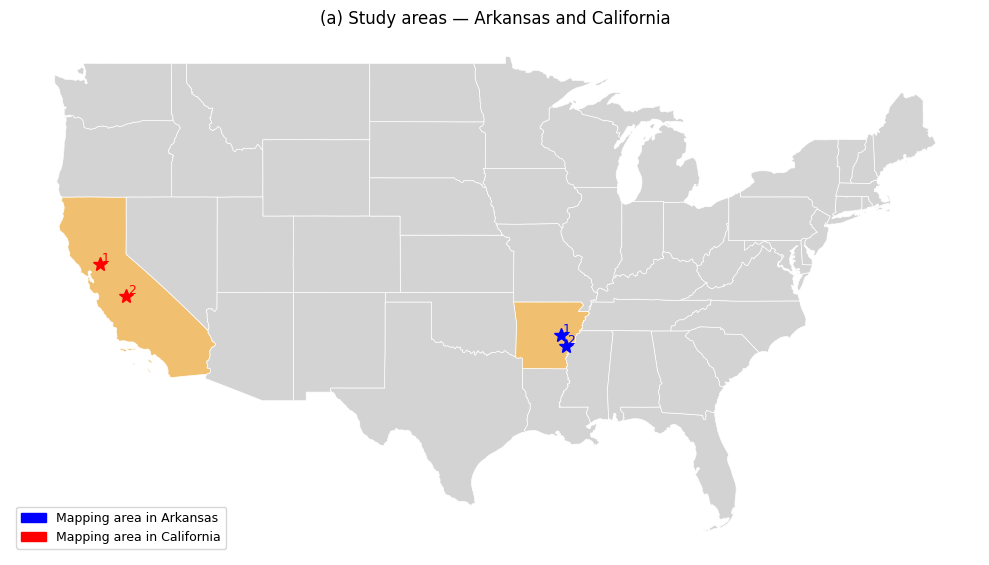

In [25]:
url = 'https://www2.census.gov/geo/tiger/GENZ2021/shp/cb_2021_us_state_20m.zip'
states = gpd.read_file(url)
states = states[~states['NAME'].isin([
    'Alaska','Hawaii','Puerto Rico','United States Virgin Islands',
    'Guam','Commonwealth of the Northern Mariana Islands','American Samoa'
])].to_crs('EPSG:4326')

colors = ['#F0C070' if n in ['Arkansas','California'] else '#D3D3D3'
          for n in states['NAME']]

fig, ax = plt.subplots(figsize=(10, 6))
states.plot(ax=ax, color=colors, edgecolor='white', linewidth=0.5)

for lon, lat, label, color in [
    (-91.5, 34.8, '1', 'blue'), (-91.2, 34.2, '2', 'blue'),
    (-121.7, 38.5, '1', 'red'), (-120.0, 36.8, '2', 'red'),
]:
    ax.plot(lon, lat, '*', color=color, markersize=10, zorder=5)
    ax.annotate(label, (lon+0.1, lat+0.1), color=color, fontsize=9)

legend = [
    mpatches.Patch(color='blue', label='Mapping area in Arkansas'),
    mpatches.Patch(color='red',  label='Mapping area in California'),
]
ax.legend(handles=legend, loc='lower left', fontsize=9)
ax.set_title('(a) Study areas — Arkansas and California', fontsize=12)
ax.axis('off')
plt.tight_layout()
plt.savefig(f'{sauv_dir}/fig1a_study_areas.png', dpi=300)
plt.show()


## Découper CDL sur les zones mapping

In [26]:
project = pyproj.Transformer.from_crs('EPSG:4326','EPSG:5070',always_xy=True).transform

def crop_cdl(tif_path, bbox_wgs):
    geom = transform(project, box(*bbox_wgs))
    with rasterio.open(tif_path) as src:
        data, _ = rasterio.mask.mask(src, [geom], crop=True)
    return data[0]

ark1_data = crop_cdl(TIF_ARK, (-91.8, 34.6, -91.3, 35.0))
ark2_data = crop_cdl(TIF_ARK, (-91.5, 34.0, -91.0, 34.4))
cal1_data = crop_cdl(TIF_CAL, (-121.9, 38.3, -121.4, 38.7))
cal2_data = crop_cdl(TIF_CAL, (-120.2, 36.6, -119.7, 37.0))

for name, d in [('Arkansas Z1',ark1_data),('Arkansas Z2',ark2_data),
                ('California Z1',cal1_data),('California Z2',cal2_data)]:
    print(f'{name} : {d.shape}  | valeurs uniques : {len(np.unique(d))}')

Arkansas Z1 : (1561, 1582)  | valeurs uniques : 37
Arkansas Z2 : (1566, 1598)  | valeurs uniques : 39
California Z1 : (1825, 1787)  | valeurs uniques : 79
California Z2 : (1815, 1800)  | valeurs uniques : 71


## Cartes CDL Arkansas (Fig. 1b)

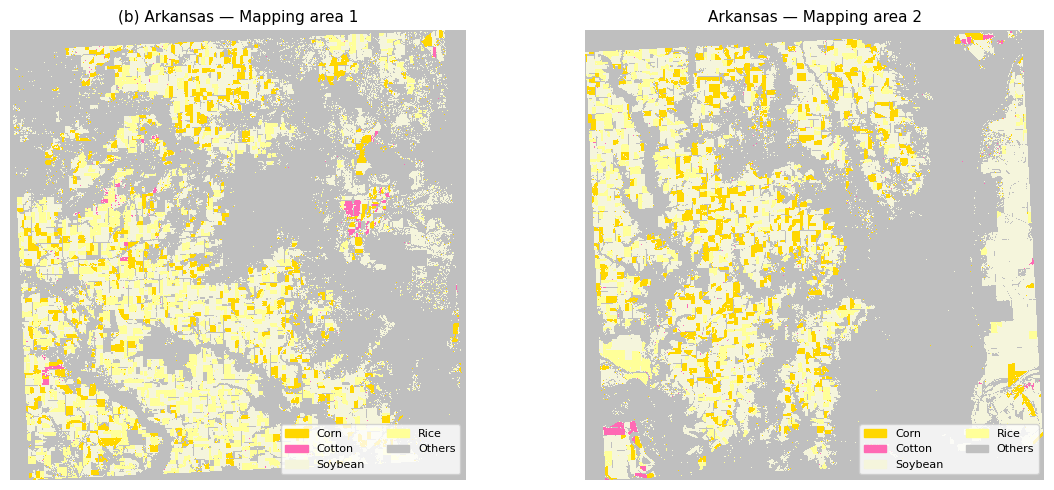

In [27]:
def make_rgb(data, color_map):
    h, w = data.shape
    rgb = np.ones((h, w, 3)) * 0.75
    for code, (hex_c, _) in color_map.items():
        if code == 0: continue
        r,g,b = int(hex_c[1:3],16)/255, int(hex_c[3:5],16)/255, int(hex_c[5:7],16)/255
        rgb[data == code] = [r,g,b]
    return rgb

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, data, title in zip(axes,
    [ark1_data, ark2_data],
    ['(b) Arkansas — Mapping area 1', 'Arkansas — Mapping area 2']):
    ax.imshow(make_rgb(data, CDL_COLORS_ARK), interpolation='nearest')
    ax.set_title(title, fontsize=11)
    ax.axis('off')
    patches = [mpatches.Patch(color=c, label=l) for _,(c,l) in CDL_COLORS_ARK.items()]
    ax.legend(handles=patches, loc='lower right', fontsize=8, ncol=2)
plt.tight_layout()
plt.savefig(f'{sauv_dir}/fig1b_arkansas_cdl.png', dpi=300)
plt.show()


## Cartes CDL California (Fig. 1c)

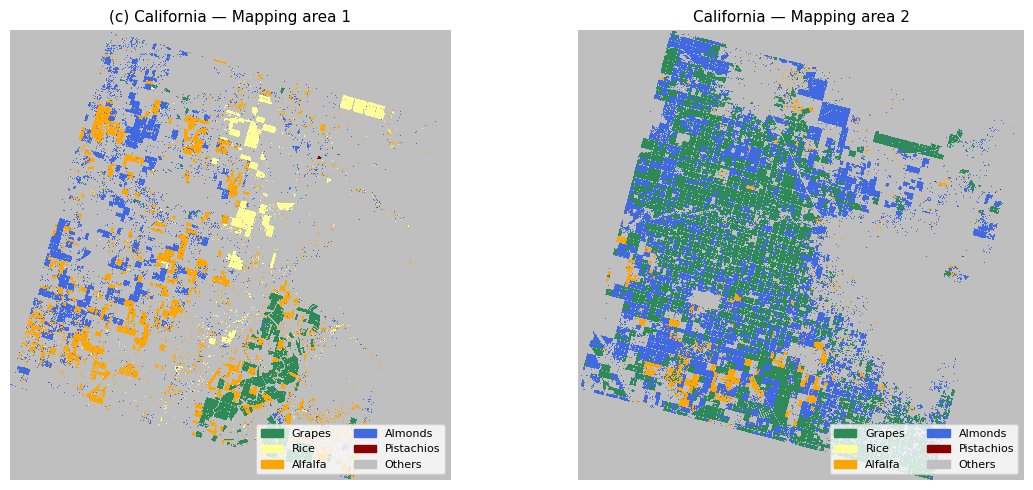

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, data, title in zip(axes,
    [cal1_data, cal2_data],
    ['(c) California — Mapping area 1', 'California — Mapping area 2']):
    ax.imshow(make_rgb(data, CDL_COLORS_CAL), interpolation='nearest')
    ax.set_title(title, fontsize=11)
    ax.axis('off')
    patches = [mpatches.Patch(color=c, label=l) for _,(c,l) in CDL_COLORS_CAL.items()]
    ax.legend(handles=patches, loc='lower right', fontsize=8, ncol=2)
plt.tight_layout()
plt.savefig(f'{sauv_dir}/fig1c_california_cdl.png', dpi=300)
plt.show()

## Figure 1 complète

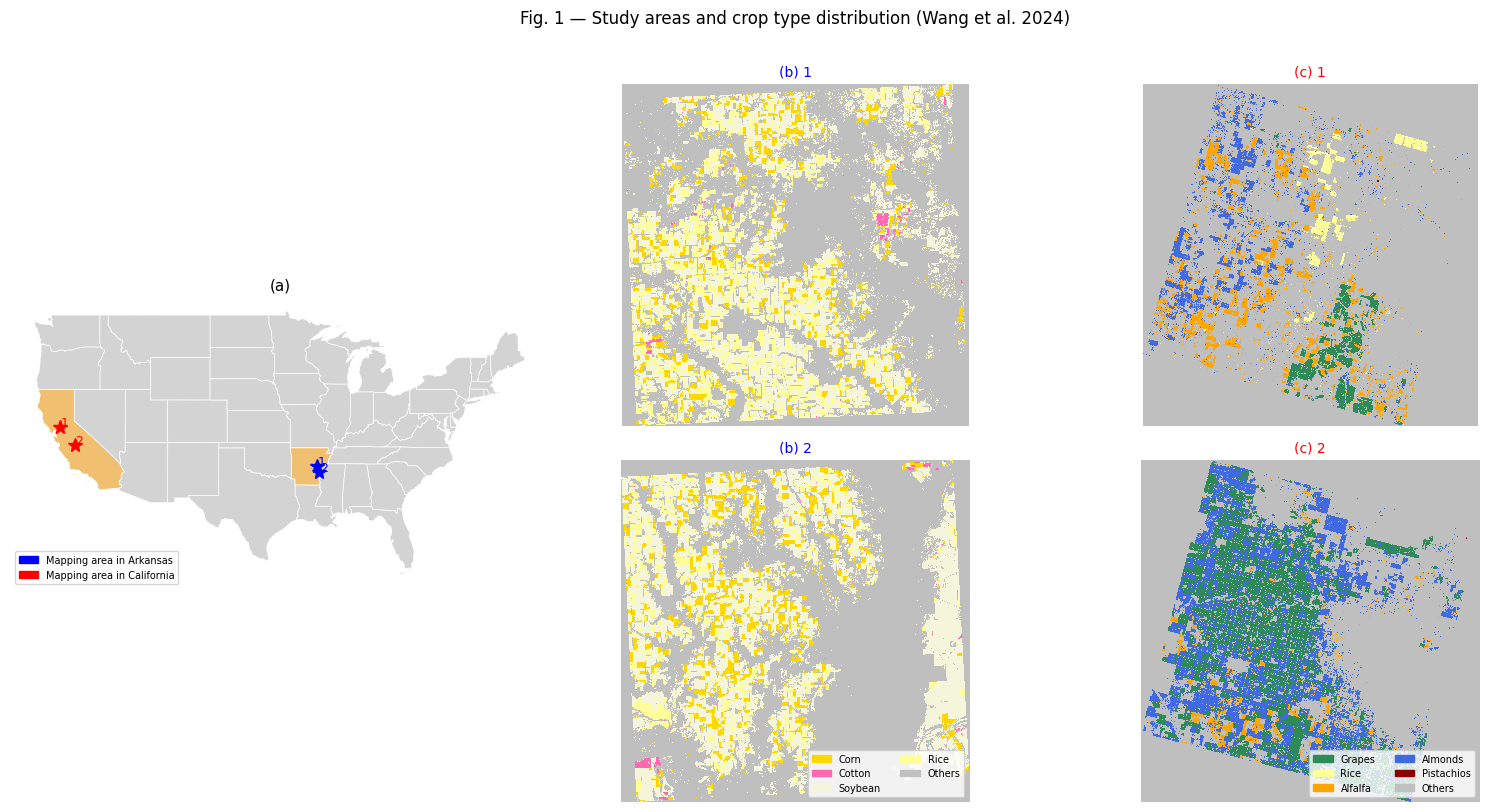

In [29]:
fig = plt.figure(figsize=(16, 8))
ax_a  = fig.add_subplot(1, 3, 1)
ax_b1 = fig.add_subplot(2, 3, 2)
ax_b2 = fig.add_subplot(2, 3, 5)
ax_c1 = fig.add_subplot(2, 3, 3)
ax_c2 = fig.add_subplot(2, 3, 6)

# (a) Carte US
states.plot(ax=ax_a, color=colors, edgecolor='white', linewidth=0.5)
for lon,lat,lbl,col in [(-91.5,34.8,'1','blue'),(-91.2,34.2,'2','blue'),
                         (-121.7,38.5,'1','red'),(-120.0,36.8,'2','red')]:
    ax_a.plot(lon,lat,'*',color=col,markersize=10,zorder=5)
    ax_a.annotate(lbl,(lon+0.1,lat+0.1),color=col,fontsize=9)
ax_a.legend(handles=[
    mpatches.Patch(color='blue',label='Mapping area in Arkansas'),
    mpatches.Patch(color='red', label='Mapping area in California')
], loc='lower left', fontsize=7)
ax_a.set_title('(a)', fontsize=11)
ax_a.axis('off')

# (b) Arkansas
for ax,data,lbl in [(ax_b1,ark1_data,'1'),(ax_b2,ark2_data,'2')]:
    ax.imshow(make_rgb(data,CDL_COLORS_ARK),interpolation='nearest')
    ax.set_title(f'(b) {lbl}',fontsize=10,color='blue')
    ax.axis('off')
ax_b2.legend(handles=[mpatches.Patch(color=c,label=l) for _,(c,l) in CDL_COLORS_ARK.items()],
             loc='lower right',fontsize=7,ncol=2)

# (c) California
for ax,data,lbl in [(ax_c1,cal1_data,'1'),(ax_c2,cal2_data,'2')]:
    ax.imshow(make_rgb(data,CDL_COLORS_CAL),interpolation='nearest')
    ax.set_title(f'(c) {lbl}',fontsize=10,color='red')
    ax.axis('off')
ax_c2.legend(handles=[mpatches.Patch(color=c,label=l) for _,(c,l) in CDL_COLORS_CAL.items()],
             loc='lower right',fontsize=7,ncol=2)

plt.suptitle('Fig. 1 — Study areas and crop type distribution (Wang et al. 2024)',fontsize=12,y=1.01)
plt.tight_layout()
plt.savefig(f'{sauv_dir}/fig1_combined.png', dpi=300, bbox_inches='tight')
plt.show()

## Distribution des classes CDL par zone

=== Arkansas — Zone 1 ===


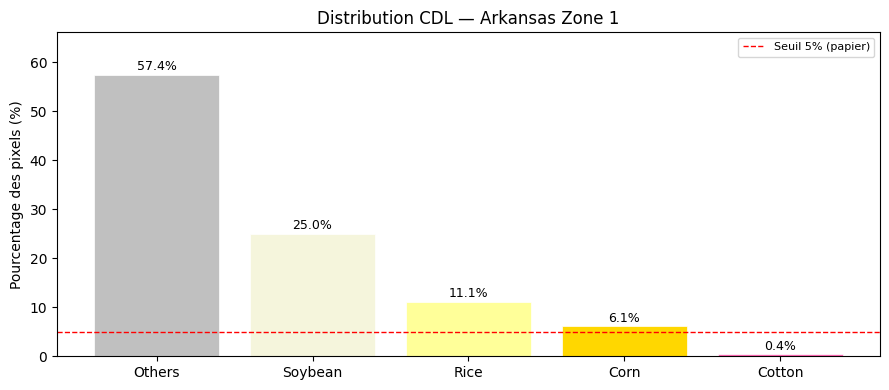

=== Arkansas — Zone 2 ===


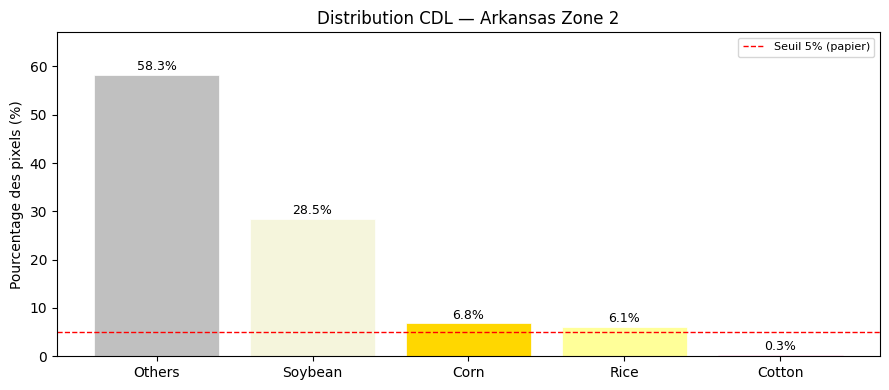

=== California — Zone 1 ===


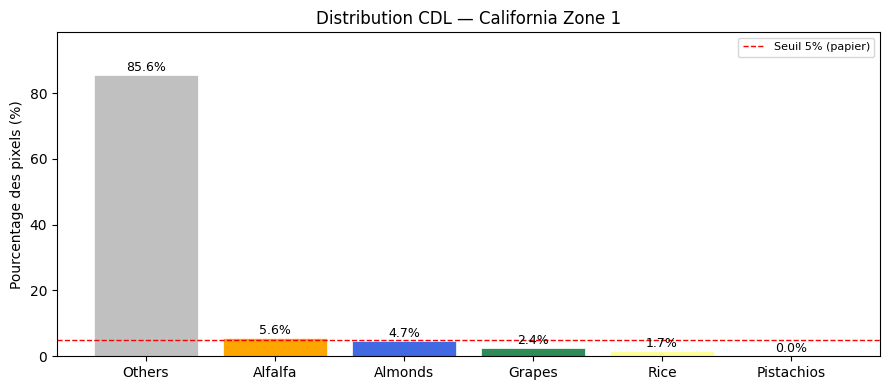

=== California — Zone 2 ===


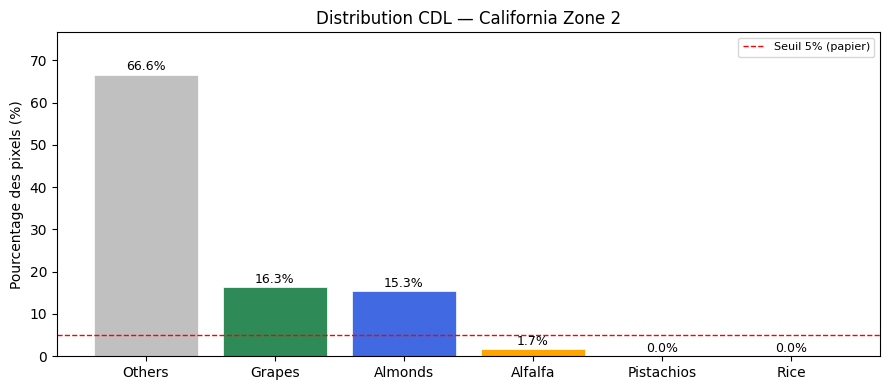

In [30]:
def class_distribution(data, class_map, color_map, title):
    total = data.size
    counts = {name: int(np.sum(data==code)) for code,name in class_map.items()}
    counts['Others'] = total - sum(counts.values())
    counts = dict(sorted(counts.items(), key=lambda x: x[1], reverse=True))
    pcts = {k: v/total*100 for k,v in counts.items()}

    color_lookup = {name: c for _,(c,name) in color_map.items()}
    bar_colors = [color_lookup.get(k,'#C0C0C0') for k in pcts]

    fig, ax = plt.subplots(figsize=(9,4))
    bars = ax.bar(pcts.keys(), pcts.values(), color=bar_colors,
                  edgecolor='white', linewidth=0.5)
    for bar,(_,pct) in zip(bars,pcts.items()):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
                f'{pct:.1f}%', ha='center', va='bottom', fontsize=9)
    ax.set_ylabel('Pourcentage des pixels (%)')
    ax.set_title(title, fontsize=12)
    ax.set_ylim(0, max(pcts.values())*1.15)
    # ligne 5% (papier : classes <5% → Others)
    ax.axhline(y=5, color='red', linestyle='--', linewidth=1,
               label='Seuil 5% (papier)')
    ax.legend(fontsize=8)
    plt.tight_layout()
    plt.savefig(f'{sauv_dir}/{title.lower().replace(" ","_")}.png', dpi=300)
    plt.show()
    return pcts

print('=== Arkansas — Zone 1 ===')
pct_ark1 = class_distribution(ark1_data,CDL_CLASSES_ARK,CDL_COLORS_ARK,'Distribution CDL — Arkansas Zone 1')
print('=== Arkansas — Zone 2 ===')
pct_ark2 = class_distribution(ark2_data,CDL_CLASSES_ARK,CDL_COLORS_ARK,'Distribution CDL — Arkansas Zone 2')
print('=== California — Zone 1 ===')
pct_cal1 = class_distribution(cal1_data,CDL_CLASSES_CAL,CDL_COLORS_CAL,'Distribution CDL — California Zone 1')
print('=== California — Zone 2 ===')
pct_cal2 = class_distribution(cal2_data,CDL_CLASSES_CAL,CDL_COLORS_CAL,'Distribution CDL — California Zone 2')

---
# PARTIE 2 — Sentinel-2 L2A
Source : Copernicus Data Space — 10 bandes × 36 timesteps

## Métadonnées Sentinel-2

In [3]:

import rasterio
from pathlib import Path

def check_dataset(folder):
    bad = []
    for f in Path(folder).glob("*.tif"):
        try:
            with rasterio.open(f) as src:
                _ = src.count
        except Exception:
            bad.append(f)
    return bad

#bad_files = check_dataset("data/raw/sentinel2/arkansas") + check_dataset("data/raw/sentinel2/california")
bad_files = check_dataset("data/raw/sentinel2/california")

print("Corrompus :", len(bad_files))
for b in bad_files:
    print(b)
    

Corrompus : 0


In [4]:
# Bandes du papier Section 2.2.3
# "Band 1, 9, 10 excluded (60m resolution)"
BANDS = ['B02','B03','B04','B05','B06','B07','B08','B8A','B11','B12']

def get_valid_tifs(s2_dir):
    """Retourne (valid_tifs, corrupted_tifs) — sépare les bons des corrompus."""
    valid, corrupted = [], []
    for f in sorted(Path(s2_dir).glob('S2_*_2021_T*.tif')):
        try:
            with rasterio.open(f) as src:
                _ = src.count   # lecture minimale pour détecter la corruption
            valid.append(f)
        except Exception:
            corrupted.append(f)
    return valid, corrupted

valid_tifs = {}   # stocké pour les cellules suivantes

for region, s2_dir in [('Arkansas', S2_DIR_ARK), ('California', S2_DIR_CAL)]:
    all_tifs = sorted(s2_dir.glob('S2_*_2021_T*.tif'))
    valid, corrupted = get_valid_tifs(s2_dir)
    valid_tifs[region] = valid

    print(f'=== {region} ===')
    print(f'  Total trouvés  : {len(all_tifs)} / 36')
    print(f'  Valides        : {len(valid)}')
    print(f'  Corrompus      : {len(corrupted)}')
    if corrupted:
        for c in corrupted:
            print(f'    ⚠️  {c.name}')

    if not valid:
        print('  [!] Aucun GeoTIFF valide disponible')
        print()
        continue

    # inspecte le premier fichier VALIDE
    first_valid = valid[0]
    with rasterio.open(first_valid) as src:
        print(f'  Fichier référence  : {first_valid.name}')
        print(f'  Bandes par fichier : {src.count}')
        print(f'  Résolution         : {src.res} m')
        print(f'  CRS                : {src.crs}')
        print(f'  Taille pixels      : {src.width}x{src.height}')
        size_mb = first_valid.stat().st_size / 1e6
        print(f'  Taille fichier     : {size_mb:.0f} MB')
        total_gb = size_mb * len(all_tifs) / 1000
        print(f'  Taille totale est. : {total_gb:.1f} GB')
        descs = [src.descriptions[i] for i in range(src.count)]
        print(f'  Descriptions       : {descs}')
    print()

=== Arkansas ===
  Total trouvés  : 27 / 36
  Valides        : 27
  Corrompus      : 0
  Fichier référence  : S2_arkansas_2021_T01.tif
  Bandes par fichier : 10
  Résolution         : (10.0, 10.0) m
  CRS                : EPSG:32615
  Taille pixels      : 10980x10980
  Taille fichier     : 81 MB
  Taille totale est. : 2.2 GB
  Descriptions       : ['B02', 'B03', 'B04', 'B08', 'B05', 'B06', 'B07', 'B8A', 'B11', 'B12']

=== California ===
  Total trouvés  : 36 / 36
  Valides        : 36
  Corrompus      : 0
  Fichier référence  : S2_california_2021_T01.tif
  Bandes par fichier : 10
  Résolution         : (10.0, 10.0) m
  CRS                : EPSG:32610
  Taille pixels      : 10980x10980
  Taille fichier     : 4295 MB
  Taille totale est. : 154.6 GB
  Descriptions       : ['B02', 'B03', 'B04', 'B08', 'B05', 'B06', 'B07', 'B8A', 'B11', 'B12']



## Couverture temporelle : timesteps disponibles

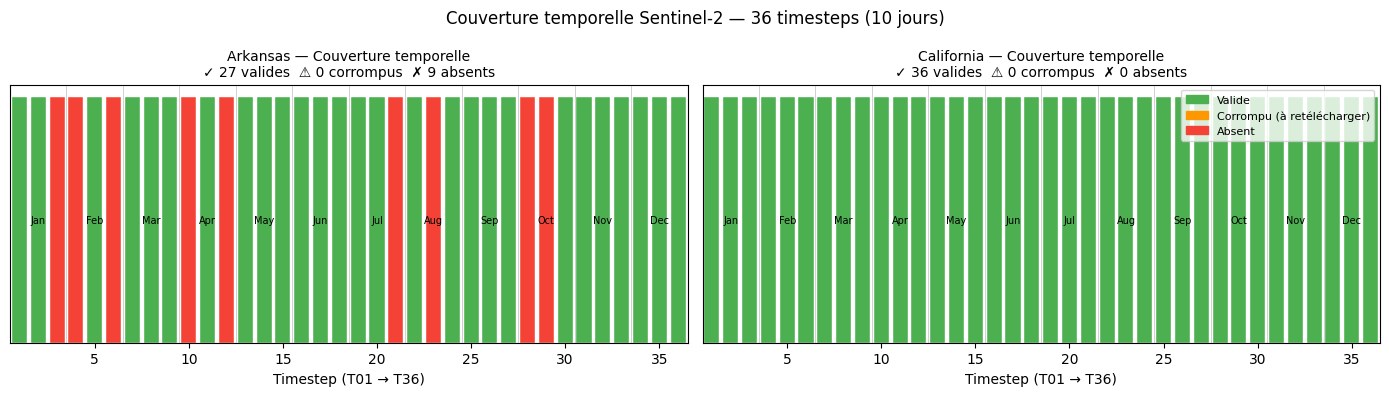

In [5]:
# Fenêtres de 10 jours (papier Section 2.2.4)
windows = []
day = 1
for month in range(1, 13):
    _, last = monthrange(2021, month)
    windows += [
        (day,     day+9,    f'T{len(windows)+1:02d}'),
        (day+10,  day+19,   f'T{len(windows)+2:02d}'),
        (day+20,  day+last-1, f'T{len(windows)+3:02d}'),
    ]
    day += last
windows = windows[:36]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for ax, (region, s2_dir) in zip(axes, [('Arkansas',S2_DIR_ARK),('California',S2_DIR_CAL)]):
    all_tifs = sorted(s2_dir.glob('S2_*_2021_T*.tif'))
    valid    = valid_tifs.get(region, [])
    found    = {int(p.stem.split('_T')[-1]) for p in all_tifs}
    valid_idx = {int(p.stem.split('_T')[-1]) for p in valid}
    corrupted_idx = found - valid_idx
    missing_idx   = set(range(1, 37)) - found

    # vert = valide, orange = corrompu, rouge = absent
    bar_colors = []
    for t in range(1, 37):
        if t in valid_idx:     bar_colors.append('#4CAF50')
        elif t in corrupted_idx: bar_colors.append('#FF9800')
        else:                  bar_colors.append('#F44336')

    ax.bar(range(1, 37), [1]*36, color=bar_colors, edgecolor='white', linewidth=0.3)
    ax.set_xlabel('Timestep (T01 → T36)', fontsize=10)
    ax.set_title(f'{region} — Couverture temporelle\n'
                 f'✓ {len(valid_idx)} valides  ⚠ {len(corrupted_idx)} corrompus  ✗ {len(missing_idx)} absents',
                 fontsize=10)
    ax.set_yticks([])
    ax.set_xlim(0.5, 36.5)
    months = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
    for i, m in enumerate(months):
        ax.axvline(x=i*3+0.5, color='gray', linewidth=0.5, alpha=0.5)
        ax.text(i*3+2, 0.5, m, ha='center', va='center', fontsize=7)

legend = [
    mpatches.Patch(color='#4CAF50', label='Valide'),
    mpatches.Patch(color='#FF9800', label='Corrompu (à retélécharger)'),
    mpatches.Patch(color='#F44336', label='Absent'),
]
axes[1].legend(handles=legend, fontsize=8, loc='upper right')
plt.suptitle('Couverture temporelle Sentinel-2 — 36 timesteps (10 jours)', fontsize=12)
plt.tight_layout()
plt.savefig(f'{sauv_dir}/fig2_temporal_coverage.png', dpi=300)
plt.show()

## Visualisation RGB Sentinel-2 (True Color) par timestep

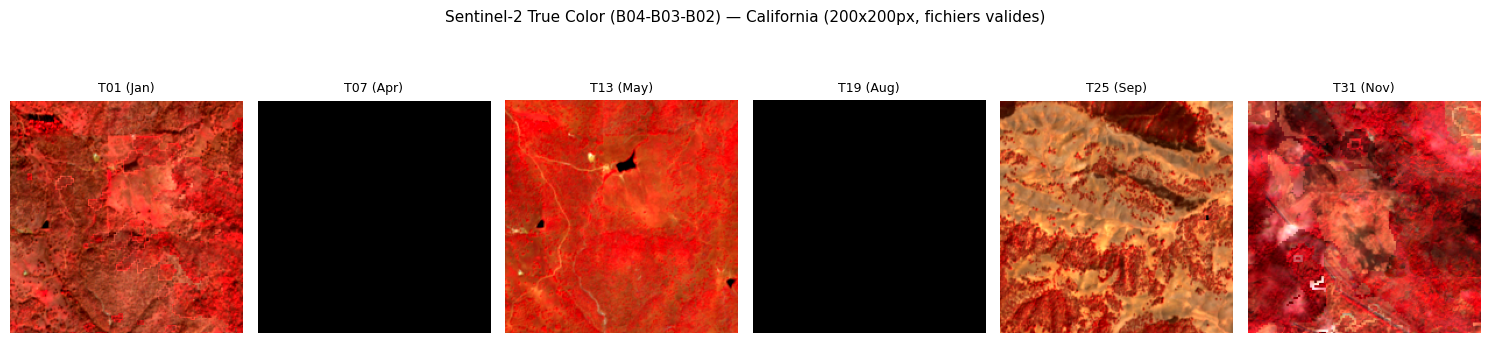

In [14]:
def read_rgb(tif_path, crop_size=(200, 200), band_indices=(4, 3, 2)):
    """Lit uniquement les bandes B04, B03, B02 et charge une petite fenêtre pour économiser la mémoire."""
    from rasterio.windows import Window
    window = Window(0, 0, crop_size[1], crop_size[0])
    with rasterio.open(tif_path) as src:
        data = src.read(band_indices, window=window)
    rgb = np.stack(data, axis=-1).astype(np.float32)
    valid_pixels = rgb[rgb > 0]
    if valid_pixels.size == 0:
        # cas où la fenêtre est totalement masquée / vide
        return np.clip(rgb / 10000.0, 0, 1)
    p2, p98 = np.percentile(valid_pixels, [2, 98])
    if p98 <= p2:
        return np.clip(rgb / 10000.0, 0, 1)
    return np.clip((rgb - p2) / (p98 - p2 + 1e-8), 0, 1)

# Affiche 6 timesteps valides pour Arkansas et California

def plot_rgb_region(region, valid_tifs, crop_size=(200, 200)):
    valid = valid_tifs.get(region, [])
    if not valid:
        print(f'[!] Aucun GeoTIFF {region} valide disponible')
        return

    step = max(1, len(valid) // 6)
    selected = valid[::step][:6]
    months_labels = ['Jan','Apr','May','Aug','Sep','Nov']

    fig, axes = plt.subplots(1, len(selected), figsize=(15, 4))
    if len(selected) == 1:
        axes = [axes]

    for ax, tif, mlabel in zip(axes, selected, months_labels[:len(selected)]):
        rgb = read_rgb(tif, crop_size=crop_size)
        ax.imshow(rgb)
        t_num = tif.stem.split('_T')[-1]
        ax.set_title(f'T{t_num} ({mlabel})', fontsize=9)
        ax.axis('off')

    plt.suptitle(
        f'Sentinel-2 True Color (B04-B03-B02) — {region} ({crop_size[0]}x{crop_size[1]}px, fichiers valides)',
        fontsize=11
    )
    plt.tight_layout()
    plt.savefig(f'{sauv_dir}/fig3_sentinel2_rgb_{region.lower()}.png', dpi=150)
    plt.show()

#plot_rgb_region('Arkansas', valid_tifs)
plot_rgb_region('California', valid_tifs)

## Distribution des 10 bandes spectrales (1 timestep)

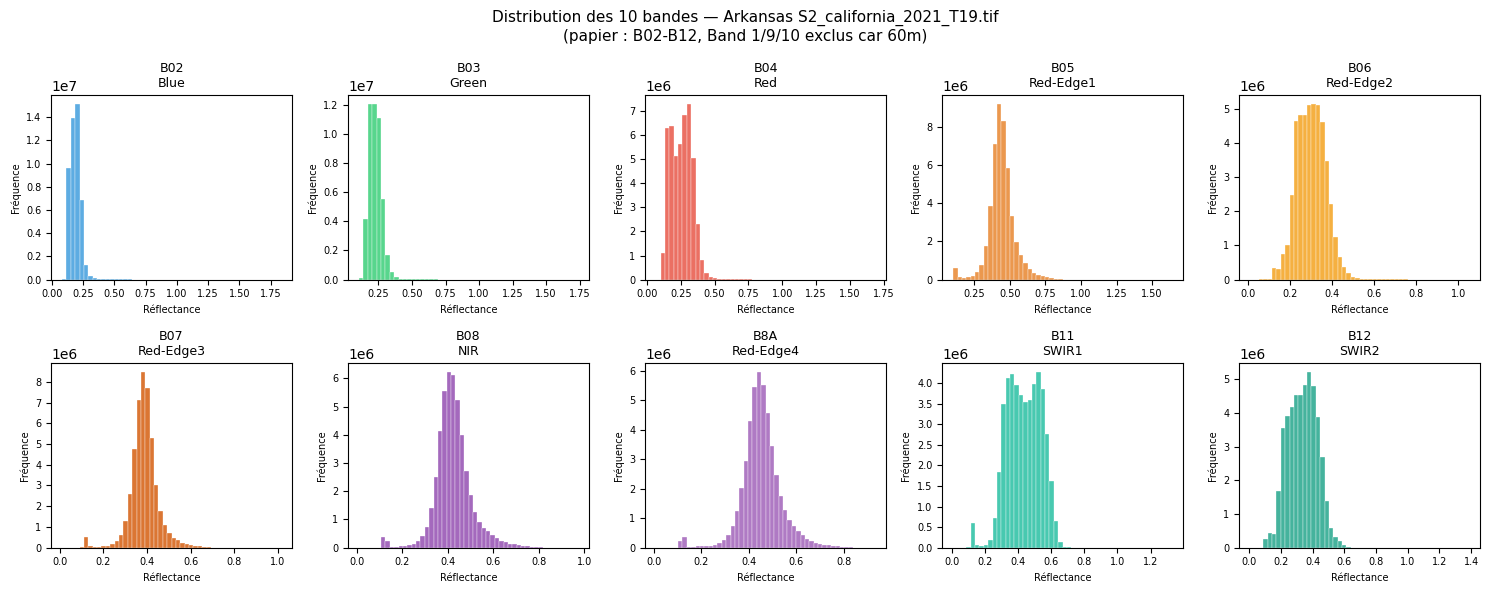

In [ ]:
BANDS = ['B02','B03','B04','B05','B06','B07','B08','B8A','B11','B12']
BAND_LABELS = [
    'B02\nBlue','B03\nGreen','B04\nRed',
    'B05\nRed-Edge1','B06\nRed-Edge2','B07\nRed-Edge3',
    'B08\nNIR','B8A\nRed-Edge4','B11\nSWIR1','B12\nSWIR2'
]

valid_ark = valid_tifs.get('Arkansas', [])
if valid_ark:
    # cherche T19 (juillet) parmi les valides, sinon prend le milieu
    july_files = [t for t in valid_ark if 'T19' in t.name]
    tif_use    = july_files[0] if july_files else valid_ark[len(valid_ark)//2]

    with rasterio.open(tif_use) as src:
        data    = src.read()
        n_bands = min(src.count, 10)

    colors_bands = ['#3498db','#2ecc71','#e74c3c','#e67e22','#f39c12',
                    '#d35400','#8e44ad','#9b59b6','#1abc9c','#16a085']

    fig, axes = plt.subplots(2, 5, figsize=(15, 6))
    for i, ax in enumerate(axes.flatten()):
        if i >= n_bands:
            ax.axis('off')
            continue
        band_data = data[i].flatten()
        band_data = band_data[band_data > 0]
        if len(band_data) > 0:
            ax.hist(band_data / 10000, bins=50, color=colors_bands[i],
                    edgecolor='white', linewidth=0.3, alpha=0.8)
        ax.set_title(BAND_LABELS[i] if i < len(BAND_LABELS) else f'Band {i+1}', fontsize=9)
        ax.set_xlabel('Réflectance', fontsize=7)
        ax.set_ylabel('Fréquence', fontsize=7)
        ax.tick_params(labelsize=7)

    plt.suptitle(f'Distribution des 10 bandes — Arkansas {tif_use.name}\n'
                 f'(papier : B02-B12, Band 1/9/10 exclus car 60m)',fontsize=11)
    plt.tight_layout()
    plt.savefig(f'{sauv_dir}/fig4_band_distributions.png', dpi=150)
    plt.show()
else:
    print('[!] Aucun GeoTIFF Arkansas valide')

## Taux de données manquantes par mois (couverture nuageuse)

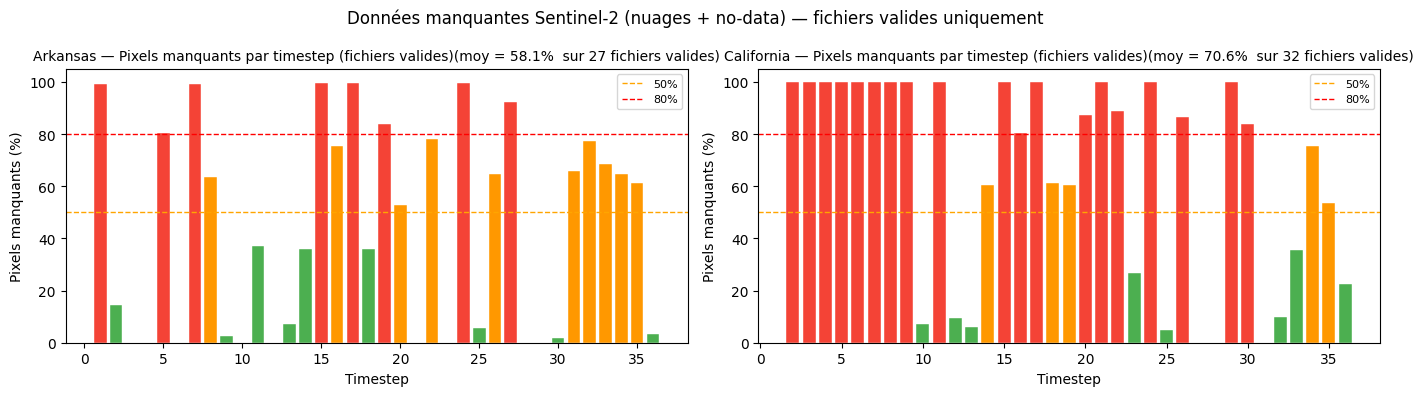

In [36]:
# % pixels à 0 par timestep = données manquantes / nuages
# Papier : 'still missing data in sequences, used 0 to mark missing data'

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for ax, (region, s2_dir) in zip(axes, [('Arkansas',S2_DIR_ARK),('California',S2_DIR_CAL)]):
    valid = valid_tifs.get(region, [])
    if not valid:
        ax.text(0.5, 0.5, 'Aucun fichier valide', ha='center', va='center',
                transform=ax.transAxes, fontsize=12)
        ax.set_title(region)
        continue

    missing_rates, t_indices = [], []
    for tif in valid:
        t_idx = int(tif.stem.split('_T')[-1])
        with rasterio.open(tif) as src:
            band = src.read(1)
            miss = (band == 0).mean() * 100
            missing_rates.append(miss)
            t_indices.append(t_idx)

    ax.bar(t_indices, missing_rates,
           color=['#F44336' if m > 80 else '#FF9800' if m > 50 else '#4CAF50'
                  for m in missing_rates],
           edgecolor='white', linewidth=0.3)
    ax.axhline(y=50, color='orange', linestyle='--', linewidth=1, label='50%')
    ax.axhline(y=80, color='red',    linestyle='--', linewidth=1, label='80%')
    ax.set_xlabel('Timestep')
    ax.set_ylabel('Pixels manquants (%)')
    ax.set_title(f'{region} — Pixels manquants par timestep (fichiers valides)(moy = {np.mean(missing_rates):.1f}%  sur {len(valid)} fichiers valides)', fontsize=10)
    ax.legend(fontsize=8)
    ax.set_ylim(0, 105)

plt.suptitle('Données manquantes Sentinel-2 (nuages + no-data) — fichiers valides uniquement',
             fontsize=12)
plt.tight_layout()
plt.savefig(f'{sauv_dir}/fig5_missing_data.png', dpi=300)
plt.show()

---
# PARTIE 3 — ESA WorldCover 2021 (Masque cropland )

In [37]:
from rasterio.merge import merge

WC_TILES = {
    'arkansas': [
        's3://esa-worldcover/v200/2021/map/ESA_WorldCover_10m_2021_v200_N33W093_Map.tif',
        's3://esa-worldcover/v200/2021/map/ESA_WorldCover_10m_2021_v200_N33W090_Map.tif',
    ],
    'california': [
        's3://esa-worldcover/v200/2021/map/ESA_WorldCover_10m_2021_v200_N36W123_Map.tif',
        's3://esa-worldcover/v200/2021/map/ESA_WorldCover_10m_2021_v200_N36W120_Map.tif',
    ],
}

# Classes WorldCover
WC_CLASSES = {
    10: ('Tree cover',        '#006400'),
    20: ('Shrubland',         '#FFBB22'),
    30: ('Grassland',         '#FFFF4C'),
    40: ('Cropland',          '#F096FF'),   # ← classe utilisée pour le masque
    50: ('Built-up',          '#FA0000'),
    60: ('Bare/sparse veg',   '#B4B4B4'),
    70: ('Snow and ice',      '#F0F0F0'),
    80: ('Water bodies',      '#0064C8'),
    90: ('Herbaceous wetland','#0096A0'),
   100: ('Moss and lichen',   '#FAE6A0'),
}

wc_data_regions = {}

for region, bbox in [('arkansas',(-92.0,34.0,-90.0,35.5)),
                     ('california',(-121.5,36.5,-119.5,38.0))]:
    west, south, east, north = bbox
    print(f'Chargement WorldCover — {region}...')
    datasets = []
    for url in WC_TILES[region]:
        try:
            src = rasterio.open(url)
            b = src.bounds
            if b.right>west and b.left<east and b.top>south and b.bottom<north:
                datasets.append(src)
                print(f'  ✓ {url.split("/")[-1]}')
        except Exception as e:
            print(f'  ✗ {url.split("/")[-1]} — {e}')

    if datasets:
        merged, _ = merge(datasets, bounds=(west,south,east,north))
        wc_data_regions[region] = merged[0]
        for ds in datasets: ds.close()
        print(f'  Shape : {merged[0].shape}')
    else:
        print(f'  [!] Aucune tuile accessible')

Chargement WorldCover — arkansas...
  ✓ ESA_WorldCover_10m_2021_v200_N33W093_Map.tif
  Shape : (18000, 24000)
Chargement WorldCover — california...
  ✓ ESA_WorldCover_10m_2021_v200_N36W123_Map.tif
  ✓ ESA_WorldCover_10m_2021_v200_N36W120_Map.tif
  Shape : (18000, 24000)


## Visualisation WorldCover + proportion cropland

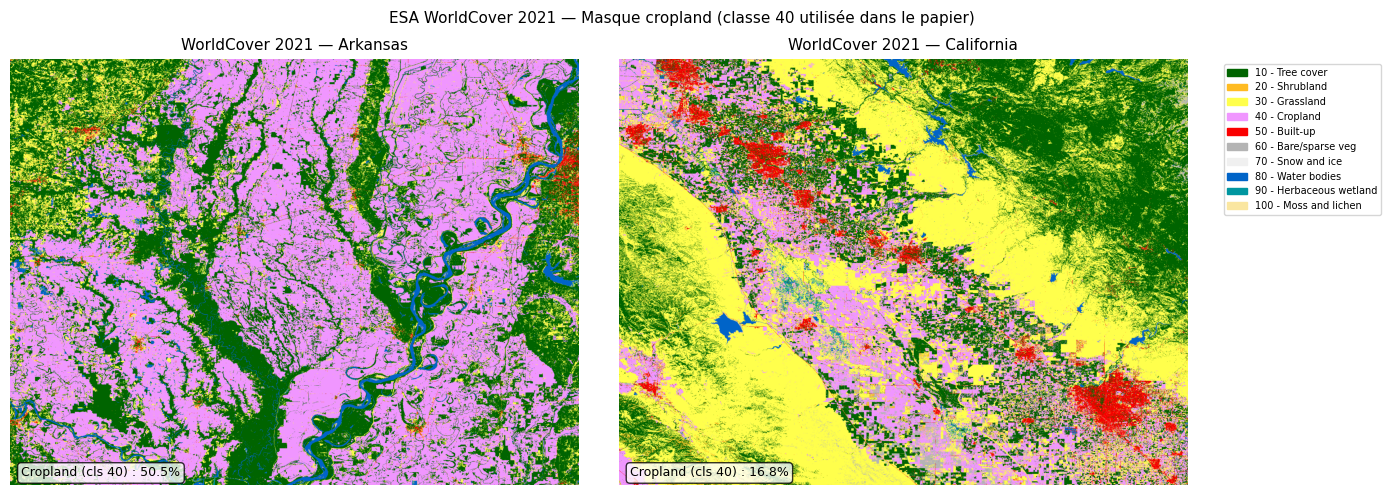

In [38]:
if wc_data_regions:
    fig, axes = plt.subplots(1, len(wc_data_regions), figsize=(14, 5))

    if len(wc_data_regions) == 1:
        axes = [axes]

    for ax, (region, wc) in zip(axes, wc_data_regions.items()):

        h, w = wc.shape
        max_size = 2000  # max pixels (ajuste si besoin)

        scale = max(h / max_size, w / max_size, 1)
        if scale > 1:
            step = int(scale)
            wc = wc[::step, ::step]
            h, w = wc.shape

        rgb = np.ones((h, w, 3), dtype=np.uint8) * 128  # gris

        for cls, (_, hex_c) in WC_CLASSES.items():
            r = int(hex_c[1:3], 16)
            g = int(hex_c[3:5], 16)
            b = int(hex_c[5:7], 16)
            rgb[wc == cls] = [r, g, b]

        ax.imshow(rgb)
        ax.set_title(f'WorldCover 2021 — {region.capitalize()}', fontsize=11)
        ax.axis('off')

        cropland_pct = (wc == 40).mean() * 100
        ax.text(
            0.02, 0.02,
            f'Cropland (cls 40) : {cropland_pct:.1f}%',
            transform=ax.transAxes,
            fontsize=9,
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8)
        )

    patches = [
        mpatches.Patch(color=c, label=f'{cls} - {name}')
        for cls, (name, c) in WC_CLASSES.items()
    ]

    axes[-1].legend(
        handles=patches,
        loc='upper right',
        fontsize=7,
        bbox_to_anchor=(1.35, 1)
    )

    plt.suptitle(
        'ESA WorldCover 2021 — Masque cropland (classe 40 utilisée dans le papier)',
        fontsize=11
    )

    plt.tight_layout()
    plt.savefig(f'{sauv_dir}/fig6_worldcover.png', dpi=150)
    plt.show()

else:
    print('[!] WorldCover non chargé')

---
## Résumé EDA + checklist avant preprocessing

In [39]:
print('=' * 60)
print('  RÉSUMÉ EDA  ')
print('=' * 60)

print('\n── CDL 2021 (USDA) ──────────────────────────')
for region, data in [('Arkansas Z1',ark1_data),('Arkansas Z2',ark2_data),
                     ('California Z1',cal1_data),('California Z2',cal2_data)]:
    print(f'  {region:15s} : {data.shape[0]}x{data.shape[1]} pixels')

print('\n── Sentinel-2 L2A ───────────────────────────')
for region, s2_dir in [('Arkansas',S2_DIR_ARK),('California',S2_DIR_CAL)]:
    tifs = sorted(s2_dir.glob('S2_*_2021_T*.tif'))
    print(f'  {region:12s} : {len(tifs)}/36 GeoTIFFs')

print('\n── ESA WorldCover 2021 ──────────────────────')
for region, wc in wc_data_regions.items():
    print(f'  {region:12s} : {wc.shape} | cropland = {(wc==40).mean()*100:.1f}%')

print('\n── Checklist avant preprocessing ───────────')
checks = [
    ('CDL Arkansas',    TIF_ARK),
    ('CDL California',  TIF_CAL),
    ('S2 Arkansas dir', str(S2_DIR_ARK)),
    ('S2 California dir',str(S2_DIR_CAL)),
]
all_ok = True
for name, path in checks:
    exists = os.path.exists(path)
    status = '✓' if exists else '✗'
    print(f'  {status} {name:22s} : {path}')
    if not exists: all_ok = False

print()
if all_ok:
    print('  ✓ Tout est prêt → lance preprocessing_mctnet.ipynb')
else:
    print('  ⚠️  Certains fichiers manquent — compléter le téléchargement')


  RÉSUMÉ EDA  

── CDL 2021 (USDA) ──────────────────────────
  Arkansas Z1     : 1561x1582 pixels
  Arkansas Z2     : 1566x1598 pixels
  California Z1   : 1825x1787 pixels
  California Z2   : 1815x1800 pixels

── Sentinel-2 L2A ───────────────────────────
  Arkansas     : 36/36 GeoTIFFs
  California   : 36/36 GeoTIFFs

── ESA WorldCover 2021 ──────────────────────
  arkansas     : (18000, 24000) | cropland = 50.5%
  california   : (18000, 24000) | cropland = 16.8%

── Checklist avant preprocessing ───────────
  ✓ CDL Arkansas           : data\raw\cdl\arkansas\CDL_2021_05.tif
  ✓ CDL California         : data\raw\cdl\california\CDL_2021_06.tif
  ✓ S2 Arkansas dir        : data\raw\sentinel2\arkansas
  ✓ S2 California dir      : data\raw\sentinel2\california

  ✓ Tout est prêt → lance preprocessing_mctnet.ipynb
